In [1]:
import functools
import multiprocessing as mp
import os
from dataclasses import dataclass
import matplotlib.pyplot as plt

import numpy as np
import numpy.typing as npt
import scipy.stats
import shapely

from random_matrix.input_statistics import input_statistics_logger
from random_matrix.modes.mode_grid import ModeGrid
from random_matrix.utils import array_utils, geometry_utils

In [2]:
@dataclass(slots=True)
class ShapeData:
    """Mini class for storing data associated with a single shape

    lengths: unsigned lengths of sides of the shape
    angles: arctan2 type angles of the sides, thought of as vectors
            (orientation taken into account)
    exterior_angles: the exterior angles of the polygon. These are not oriented
    """

    lengths: np.ndarray
    angles: np.ndarray
    exterior_angles: np.ndarray

    def __str__(self):
        return (
            f"Lengths: {self.lengths}\n"
            f"Angles: {self.angles}\n"
            f"Exterior Angles: {self.exterior_angles}"
        )


def get_shape_data(shape: np.ndarray) -> ShapeData:
    """Method for generating ShapeData objects from arrays of vertices"""

    lengths = []
    angles = []
    exterior_angles = []

    # Find the lengths and angles of each side (thought of as a sequence of
    # vectors)
    for vertex_one, vertex_two in array_utils.get_pairs(shape, cyclic=True):
        side = vertex_two - vertex_one
        length = np.linalg.norm(side)
        lengths.append(length)

        angle = np.arctan2(side[1], side[0])
        angles.append(angle)

    lengths = np.array(lengths)
    angles = np.array(angles)

    # Get exterior angles
    for first, second in array_utils.get_pairs(angles, cyclic=True):
        exterior_angle = geometry_utils.get_small_angular_difference(
            first, second
        )
        exterior_angles.append(exterior_angle)

    exterior_angles = np.array(exterior_angles)

    data = ShapeData(
        lengths=lengths, angles=angles, exterior_angles=exterior_angles
    )

    return data


def get_angle(
    shape_data: ShapeData, reference_shape_data: ShapeData
) -> np.float64:
    """Gets the angle that the reference_shape_data would need to be rotated by
    to get the shape_data

    Angle is reduced to the inetrval [-pi, pi]
    """
    lenghts = shape_data.lengths
    lengths_reference = reference_shape_data.lengths

    angles = shape_data.angles
    angles_reference = reference_shape_data.angles

    possible_outputs = []

    # Align so that all the sides coincide
    max_roll = len(lenghts)
    for roll in (-i for i in range(max_roll)):
        rolled_lengths = np.roll(lenghts, roll)
        sides_equal = np.allclose(lengths_reference, rolled_lengths)
        if sides_equal:
            # Find rotation angle for this particular configuration
            rolled_angles = np.roll(angles, roll)
            angle = np.mod(
                scipy.stats.mode(
                    rolled_angles - angles_reference, keepdims=False
                )[0],
                2 * np.pi,
            )
            angle = angle - 2 * np.pi if angle > np.pi else angle
            possible_outputs.append(angle)
    min_index = np.argmin(np.abs(possible_outputs))
    return possible_outputs[min_index]

Lengths: [1.2 1.  1.2 1. ]
Angles: [ 0.          1.57079633  3.14159265 -1.57079633]
Exterior Angles: [1.57079633 1.57079633 1.57079633 1.57079633]
Lengths: [1.2 1.  1.2 1. ]
Angles: [ 0.          1.57079633  3.14159265 -1.57079633]
Exterior Angles: [1.57079633 1.57079633 1.57079633 1.57079633]
Lengths: [1.2 1.  1.2 1. ]
Angles: [-1.11820064  0.45259568  2.02339201 -2.68899697]
Exterior Angles: [1.57079633 1.57079633 1.57079633 1.57079633]


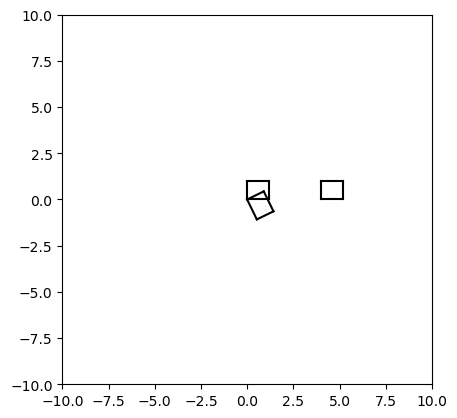

In [3]:
# Test shape data and getting the data
# np.random.seed(12)
angle = np.random.uniform(0, 2 * np.pi)
angle = geometry_utils.get_symmetric_reduced_angle(angle)

square = np.array([[0, 0], [1.2, 0], [1.2, 1], [0, 1]])
shifted_square = geometry_utils.translate_points(square, np.array([4, 0]))
rotated_square = geometry_utils.rotate_points(square, angle)

square_data = get_shape_data(square)
shifted_square_data = get_shape_data(shifted_square)
rotated_square_data = get_shape_data(rotated_square)
print(square_data)
print(shifted_square_data)
print(rotated_square_data)

fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect("equal")
for one, two in array_utils.get_pairs(square, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="black")

for one, two in array_utils.get_pairs(shifted_square, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="black")

for one, two in array_utils.get_pairs(rotated_square, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="black")

In [4]:
lengths = rotated_square_data.lengths
angles = rotated_square_data.angles
exterior_angles = rotated_square_data.exterior_angles

lengths_reference = square_data.lengths
angles_reference = square_data.angles
exterior_angles_reference = square_data.exterior_angles

possible_outputs = []

# Align so that all the sides coincide
max_roll = len(lengths)
for roll in (-i for i in range(max_roll)):

    # Check that the shapes are the same for this particular roll
    rolled_lengths = np.roll(lengths, roll)
    rolled_exteriors = np.roll(exterior_angles, roll)

    equal = np.allclose(lengths_reference, rolled_lengths) & np.allclose(
        exterior_angles_reference, rolled_exteriors
    )
    if equal:
        # Find rotation angle for this particular configuration
        print(f"Roll: {roll}")
        rolled_angles = np.roll(angles, roll)
        print(angles_reference)
        print(rolled_angles)

        angle_ref = angles_reference[0]
        angle_roll = rolled_angles[0]

        first = geometry_utils.get_unit_vector(angle_ref)
        second = geometry_utils.get_unit_vector(angle_roll)
        diff = geometry_utils.get_signed_small_angular_difference(
            first, second
        )
        possible_outputs.append(diff)
min_index = np.argmin(np.abs(possible_outputs))
angle_found = possible_outputs[min_index]
print(angle_found)
print(angle)

Roll: 0
[ 0.          1.57079633  3.14159265 -1.57079633]
[-1.11820064  0.45259568  2.02339201 -2.68899697]
Roll: -2
[ 0.          1.57079633  3.14159265 -1.57079633]
[ 2.02339201 -2.68899697 -1.11820064  0.45259568]
-1.1182006432407494
-1.1182006432407494


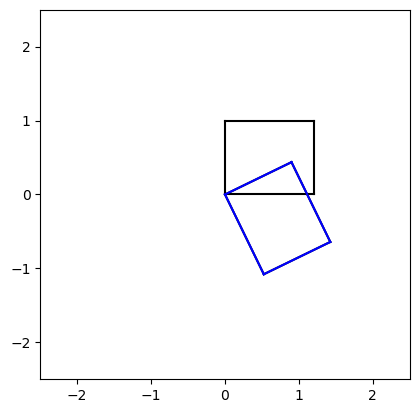

In [5]:
fig, ax = plt.subplots()
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect("equal")
for one, two in array_utils.get_pairs(square, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="black")


for one, two in array_utils.get_pairs(rotated_square, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="black")

# Rotate by another angle
new_points = geometry_utils.rotate_points(square, angle_found)
for one, two in array_utils.get_pairs(new_points, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="blue")

!!! Start the SingleShape stuff

In [6]:
@dataclass(slots=True)
class ShapeSingle:
    """Mode that has been classified according to its geometric properties.

    Attributes
    ----------

    """

    vertices: np.ndarray
    shape_data: ShapeData
    class_number: int
    mirror_type: int
    angle: float
    is_template: bool
    index: int

    @property
    def shape_data_inverted(self) -> ShapeData:
        """self.shape_data, but with all quantities going backwards"""

        inverted_lengths = self.shape_data.lengths[::-1]
        inverted_angles = self.shape_data.angles[::-1]
        inverted_exterior_angles = self.shape_data.exterior_angles[::-1]
        return ShapeData(
            lengths=inverted_lengths,
            angles=inverted_angles,
            exterior_angles=inverted_exterior_angles,
        )

    @property
    def lengths_angles(self) -> npt.NDArray:
        """Array containing the lenghts and angles"""

        lengths = self.shape_data.lengths
        angles = self.shape_data.exterior_angles
        lengths_angles = np.vstack((lengths, angles)).T
        return lengths_angles

    @property
    def lengths_angles_inverted(self) -> npt.NDArray:
        lengths_angles = self.lengths_angles
        lengths_angles_inverted = np.copy(lengths_angles[::-1])
        angles = lengths_angles_inverted[:, 1]
        rolled = np.roll(angles, -1)
        lengths_angles_inverted[:, 1] = rolled
        return lengths_angles_inverted

    @property
    def centroid(self) -> npt.NDArray:
        return np.mean(self.vertices, axis=0)

    @property
    def shapely(self) -> shapely.Polygon:
        return shapely.Polygon(self.vertices)

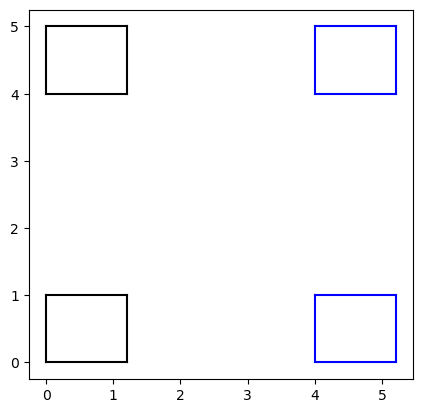

In [7]:
first = square
second = geometry_utils.translate_points(square, np.array([4, 0]))
third = geometry_utils.translate_points(square, np.array([0, 4]))
fourth = geometry_utils.translate_points(square, np.array([4, 4]))
prod = geometry_utils.iterated_cartesian_product(
    [first, second, third, fourth]
)

fig, ax= plt.subplots()
ax.set_aspect("equal")
for one, two in array_utils.get_pairs(first, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="black")

for one, two in array_utils.get_pairs(second, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="blue")

for one, two in array_utils.get_pairs(third, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="black")

for one, two in array_utils.get_pairs(fourth, True):
    ax.plot((one[0], two[0]), (one[1], two[1]), color="blue")



In [8]:
print(np.shape(prod))

(256, 8)


In [10]:
cartesian_product = geometry_utils.iterated_cartesian_product(
    [first, second, third, fourth]
)
hyperplane_normals = np.array(
    [[1, 0, -1, 0, -1, 0, 1, 0], [0, 1, 0, -1, 0, -1, 0, 1]]
).T
signs = np.sign(cartesian_product@hyperplane_normals) 

In [14]:
print(cartesian_product[:,6:8])

[[4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]
 [4.  5. ]
 [4.  4. ]
 [5.2 4. ]
 [5.2 5. ]